# Práctico 1 - Aplicación de NLP y embeddings


Para este práctico, se pide:

1. Elegir uno de los dos datasets a trabajar: reviews de IMDB ó sarcasmo (también válido: un dataset propio que consideres interesante).

1. Realizar una inspección del dataset que busque entender de qué se trata el dataset y el problema a resolver. La idea es inspeccionar no realizar un EDA completo, pueden valerse de herramientas que simplifiquen o realicen esta tarea.

1. Preprocesar los datos de texto teniendo en cuenta como baseline lo se vio anteriormente. Comparar tanto el uso de preprocesamientos típicos de NLP contra el uso de embeddings.

1. Entrenar distintos modelos y comparar sus diferencias.

1. Mostrar e Interpretar los resultados.


La notebook a presentar debe ser legible incluyendo
1. Introducción

1. Acompañar con comentarios que aporten a la interpretación de los resultados.

1. Una conclusión (breve pero no tan breve) con un resumen de lo trabajado y los resultados más representativos de acuerdo a su interpretación


In [ ]:
import json
import requests

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split


## Carga de datos

Opción 1: [dataset de reviews de IMDB](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/code)

In [ ]:
# Remueve archivo anterior (si existe)
!rm -f imdb_dataset.csv

# Usa wget para descarga
file_id = "1hK3hjvuoVUUV_kW8FyVE33iGig9wN0K3"
!wget --no-check-certificate "https://docs.google.com/uc?export=download&id={file_id}" -O imdb_dataset.csv

# Carga el dataset
with open("imdb_dataset.csv", 'r') as file:
    df_imdb = pd.read_csv(file)
    print(f"Success! Dataset loaded with {len(df_imdb)} records.")


--2025-09-14 00:38:53--  https://docs.google.com/uc?export=download&id=1hK3hjvuoVUUV_kW8FyVE33iGig9wN0K3
Resolving docs.google.com (docs.google.com)... 142.251.170.138, 142.251.170.113, 142.251.170.100, ...
Connecting to docs.google.com (docs.google.com)|142.251.170.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1hK3hjvuoVUUV_kW8FyVE33iGig9wN0K3&export=download [following]
--2025-09-14 00:38:53--  https://drive.usercontent.google.com/download?id=1hK3hjvuoVUUV_kW8FyVE33iGig9wN0K3&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 108.177.97.132, 2404:6800:4008:c06::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|108.177.97.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 66212309 (63M) [application/octet-stream]
Saving to: ‘imdb_dataset.csv’

imdb_dataset.csv    100%[===================>]  63.14M  40.9MB/

Opción 2: [dataset de sarcasmo](https://www.kaggle.com/datasets/saurabhbagchi/sarcasm-detection-through-nlp?select=Sarcasm_Headlines_Dataset.json)

In [ ]:

# Remueve archivo anterior (si existe)
!rm -f sarcasm_dataset.json
# Use wget to download
file_id = "1rLXxELrti7L0kcmBuZt47s9Mb-xZyHMB"
!wget --no-check-certificate "https://docs.google.com/uc?export=download&id={file_id}" -O sarcasm_dataset.json

# Try to load
try:
    with open("sarcasm_dataset.json", 'r') as file:
        data = json.load(file)
    print(f"Success! Dataset loaded with {len(data)} records.")
except json.JSONDecodeError:
    print("Still having issues. Let's check the file...")
    !head -5 sarcasm_dataset.json

--2025-09-14 00:39:06--  https://docs.google.com/uc?export=download&id=1rLXxELrti7L0kcmBuZt47s9Mb-xZyHMB
Resolving docs.google.com (docs.google.com)... 142.251.170.138, 142.251.170.113, 142.251.170.100, ...
Connecting to docs.google.com (docs.google.com)|142.251.170.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1rLXxELrti7L0kcmBuZt47s9Mb-xZyHMB&export=download [following]
--2025-09-14 00:39:07--  https://drive.usercontent.google.com/download?id=1rLXxELrti7L0kcmBuZt47s9Mb-xZyHMB&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 108.177.97.132, 2404:6800:4008:c06::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|108.177.97.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5616830 (5.4M) [application/octet-stream]
Saving to: ‘sarcasm_dataset.json’

sarcasm_dataset.jso 100%[===================>]   5.36M  16.

In [ ]:
df_sarcasmo = pd.read_json("sarcasm_dataset.json", lines=True)

## Selección del dataset

In [ ]:
df = df_sarcasmo  # ó df_imdb
df.head()

,article_link,headline,is_sarcastic
0,https://www.huffingtonpost.com/entry/versace-b...,former versace store clerk sues over secret 'b...,0
1,https://www.huffingtonpost.com/entry/roseanne-...,the 'roseanne' revival catches up to our thorn...,0
2,https://local.theonion.com/mom-starting-to-fea...,mom starting to fear son's web series closest ...,1
3,https://politics.theonion.com/boehner-just-wan...,"boehner just wants wife to listen, not come up...",1
4,https://www.huffingtonpost.com/entry/jk-rowlin...,j.k. rowling wishes snape happy birthday in th...,0


## Pequeña inspección de los datos

In [ ]:
seed=15

In [ ]:
X = df['headline'].values
y = df['is_sarcastic'].values

# Dividir el conjunto de datos en conjuntos de entrenamiento, validación y test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=seed)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=seed)

print(f'Cantidad de datos en train: {X_train.shape[0]}')
print(f'Cantidad de datos en validación: {X_val.shape[0]}')
print(f'Cantidad de datos en test: {X_test.shape[0]}')

Cantidad de datos en train: 18696
Cantidad de datos en validación: 4006
Cantidad de datos en test: 4007


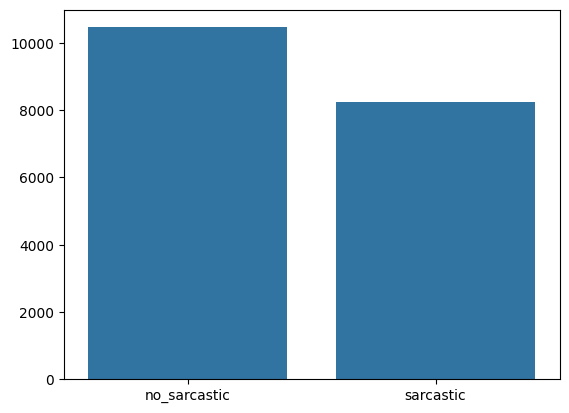

In [ ]:
target_dist = pd.Series(y_train).value_counts()
sns.barplot(x=np.array(['no_sarcastic','sarcastic']),y=target_dist.values)
plt.show()

## Procesamiento de texto y modelado


Jueguen! :)

